Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE" and remove every line containing the expression: "raise ..." (if you leave such a line your code will not run).

Do not remove any cell from the notebook you downloaded. You can add any number of cells (and remove them if not more necessary). 

## IMPORTANT: make sure to rerun all the code from the beginning to obtain the results for the final version of your notebook, since this is the way we will do it before evaluating your notebook!!!

## Make sure to name your notebook file (.ipynb) correctly:
### - The linear classification file: LC_NAMESURNAME_ID (E.g. : LC_MARIOROSSI_2204567)
### - The linear regression file: LR_NAMESURNAME_ID (E.g. : LR_MARIOROSSI_2204567)

## Fill in your name, surname and id number (numero matricola) below:

In [1]:
# Reproducible project seed, not a university registration number.
NAME = "Stelina Mukaj"
ID_number = 42  # Replace with your matricola only if submitting to the course.
import numpy as np
np.random.seed(ID_number)


---

# Linear Regression  on a Combined Cycle Power Plant (CCPP) data


## Dataset description

The dataset contains 5281 data points collected from a Combined Cycle Power Plant over 6 years (2006-2011), when the power plant was set to work with full load. Features consist of hourly average ambient variables Temperature (T), Ambient Pressure (AP), Relative Humidity (RH) and Exhaust Vacuum (V) to predict the net hourly electrical energy output (EP)  of the plant.

A combined cycle power plant (CCPP) is composed of gas turbines (GT), steam turbines (ST) and heat recovery steam generators. In a CCPP, the electricity is generated by gas and steam turbines, which are combined in one cycle, and is transferred from one turbine to another. While the Vacuum has effect on the Steam Turbine, the other three of the ambient variables effect the GT performance.

In [2]:
from __future__ import division  
import matplotlib.pyplot as plt
   
import numpy as np
import scipy as sp
from scipy import stats


In [3]:
## Import Data
# Load the data from a .csv file
np.random.seed(ID_number)

import pandas as pd
url = "https://raw.githubusercontent.com/LucaZancato/ML2020-2021/main/ccpp_Data_clean2018.csv"
data = np.array(pd.read_csv(url, sep=';'))


# A quick overview of data

In order to inspect the data you can use the method `describe()`

In [4]:
dataDescription = stats.describe(data)
print(dataDescription)

data.shape

#for more interesting visualization: use Panda!


DescribeResult(nobs=np.int64(5281), minmax=(array([  1.81,  25.36, 992.89,  25.56, 420.26]), array([  37.11,   81.56, 1033.29,  100.16,  495.23])), mean=array([  19.67317553,   54.31940163, 1013.22432115,   73.38815187,
        454.31701004]), variance=array([ 56.0327041 , 161.7733201 ,  35.2083789 , 217.43618617,
       291.84459771]), skewness=array([-0.13713412,  0.19522075,  0.24934713, -0.43467097,  0.29846615]), kurtosis=array([-1.04662553, -1.45165813,  0.01128758, -0.43044229, -1.05785395]))


(5281, 5)

# Split data in training, validation and test sets



Given $m$ total data, keep $m_t$ data as training data, $m_{val}:=m_{tv}-m_t$ as validation data and $m_{test}:=m - m_{val} - m_t = m-m_{tv}$. For instance one can take $m_t=m/3$ of the data as training, $m_{val}=m/3$  validation and $m_{test}=m/3$ as testing. Let us define as define

$\bullet$ $S_{t}$ the training data set

$\bullet$ $S_{val}$ the validation data set

$\bullet$ $S_{test}$ the testing data set


The reason for this splitting is as follows:

__TRAINING DATA__: The training data are used to compute the empirical loss
$$
L_S(h) = \frac{1}{m_t} \sum_{z_i \in S_{t}} \ell(h,z_i)
$$
which is used to estimate $\hat{h}$ (ERM) in a given model class ${\cal H}$, i.e.: 
$$
\hat{h} = {\rm arg\; min}_{h \in {\cal H}} \, L_S(h)
$$

__VALIDATION DATA__: When different model classes are present (e.g. of different complexity, such as linear regression which uses a different number $d$ of regressors $x_1,\dots,x_{d}$), one has to choose which one is the "best" complexity. 
Let ${\cal H}_{d}$ be the space of models as a function of the complexity $d$ and let 
$$
\hat h_{d} = {\rm arg\; min}_{h \in {\cal H}_{d}} \, L_S(h)
$$

One can estimate the generalization error for model $\hat h_{d}$ as follows:
$$
L_{{\cal D}}(\hat h_{d}) \simeq \frac{1}{m_{val}} \sum_{ z_i \in S_{val}} \ell(\hat h_{d},z_i)
$$
and then choose the complexity which achieves the best estimate of the generalization error
$$
\hat d: = {\rm arg\; min}_{d} \,\frac{1}{m_{val}} \sum_{ z_i \in S_{val}} \ell(\hat h_{d},z_i)
$$

__TESTING DATA__: Last, the test data set can be used to estimate the performance of the final estimated model
$\hat h_{\hat d}$, using:
$$
L_{{\cal D}}(\hat h_{\hat d}) \simeq \frac{1}{m_{test}} \sum_{ z_i \in S_{test}} \ell(\hat h_{\hat d},z_i)
$$

In [5]:
def create_train_val_test_datasets(data, m_t, m_val, m_test):
    """Shuffle once and return disjoint splits without modifying the input."""
    if min(m_t, m_val, m_test) < 0 or m_t + m_val + m_test != len(data):
        raise ValueError("Split sizes must be nonnegative and sum to the data size")
    shuffled = np.asarray(data)[np.random.permutation(len(data))]
    return shuffled[:m_t], shuffled[m_t:m_t+m_val], shuffled[m_t+m_val:]


Let's split the data in training, validation and test sets (as $m_t=m_{val} = \lfloor\frac{m}{3}\rfloor$, $m_{test} = m-m_t-m_{val}$)

In [6]:
# Let's split the data into 3 datasets
m = data.shape[0]
m_t, m_val = m // 3, m // 3
m_test = m - m_t - m_val
S_t, S_val, S_test = create_train_val_test_datasets(data, m_t, m_val, m_test)


In [7]:
assert S_t.shape    == (m_t,    data.shape[1]) # here we are comparing two tuples (it is an element wise comparison)
assert S_val.shape  == (m_val,  data.shape[1])
assert S_test.shape == (m_test, data.shape[1])


In [8]:
# Now we get input data (X) and output data (y, variable to be predicted) from S_t, S_val, S_test 
x_train, y_train = S_t[:,:-1],    S_t[:,-1].reshape(-1,1) # We use reshape so that we will get a column vector
x_val,   y_val   = S_val[:,:-1],  S_val[:,-1].reshape(-1,1)
x_test,  y_test  = S_test[:,:-1], S_test[:,-1].reshape(-1,1)
print(f"Training input data size:    {x_train.shape}")
print(f"Training output data size:   {y_train.shape}")
print(f"Validation input data size:  {x_val.shape}")
print(f"Validation output data size: {y_val.shape}")
print(f"Test input data size:        {x_test.shape}")
print(f"Test output data size:       {y_test.shape}")
# Let's get the number of features
d = x_train.shape[1]


Training input data size:    (1760, 4)
Training output data size:   (1760, 1)
Validation input data size:  (1760, 4)
Validation output data size: (1760, 1)
Test input data size:        (1761, 4)
Test output data size:       (1761, 1)


# Data Normalization

It is common practice in Statistics and Machine Learning to scale the data (= each variable) so that it is centered (zero mean) and has standard deviation equal to $1$. This helps in terms of numerical conditioning for the (inverse) problems of estimating the model (the coefficients of the linear regression in this case), as well as to give the same scale to all the coefficients. 

NOTE: Data normalization is achieved by means of a preprocessing function: the scaler. 
If you want to normalize you data to have zero (empirical) mean and unit (empirical) variance the scaler will simply be a function that takes each data point, remove the empirical mean and then divide the result by the empirical standard deviation. In this way you get a new normalized dataset. 

NORMALIZATION and TRAINING PROCEDURE:

1. You are given a training dataset, you need to find the proper scaler in order to preprocess it (e.g. use empirical mean and variance, if you want to apply the normalization by mean and variance, you could also use a different normalization for example based on the max and min) 


2. Apply the scaler to get the preprocessed training dataset 


3. Fit a model in your preferred class on the normalized dataset


4. Now you need to test your trained model on new data in order to get an estimate of the generalization error. Note you have trained you model using normalized data, this means that the model expects data that have been normalized (according to the same preprocessing step as the training data). This means that you need to apply the same scaler (that exploits the empirical mean and variance computed from the training dataset) to the test dataset (the same holds true for the validation dataset).

See next cell (note that the mean and std for the validation and test sets are not 0 and 1 respectively!)

__Remark__: Both input x and output y can be normalized!

In [9]:
# Let's standardize the our data in this case we only standardize input data X
from sklearn import preprocessing
# Find the right scaler (we are allowed to use only training data in this step)
scaler = preprocessing.StandardScaler().fit(x_train)
x_train = scaler.transform(x_train)
print(f"Mean of the training input data:   {x_train.mean(axis=0)}")
print(f"Std of the training input data:    {x_train.std(axis=0)}")
# Apply the tranformation we got with the training dataset both to the validation and test ones
x_val = scaler.transform(x_val) # use the same transformation on validation data
print(f"Mean of the validation input data: {x_val.mean(axis=0)}")
print(f"Std of the validation input data:  {x_val.std(axis=0)}")
x_test = scaler.transform(x_test) # use the same transformation on test data
print(f"Mean of the test input data:       {x_test.mean(axis=0)}")
print(f"Std of the test input data:        {x_test.std(axis=0)}")


Mean of the training input data:   [ 2.32717885e-15 -3.59762725e-15 -7.24397814e-14  7.38790342e-15]
Std of the training input data:    [1. 1. 1. 1.]
Mean of the validation input data: [ 0.06307024  0.05495274 -0.02594682 -0.00547371]
Std of the validation input data:  [0.98558871 0.99755885 1.00045436 1.00614696]
Mean of the test input data:       [ 0.00267395 -0.00931204 -0.00488129  0.0552145 ]
Std of the test input data:        [0.98372647 0.97535772 0.96549465 0.98742418]


In [10]:
# Let's wrap the code above in single function since we will need it many times
def data_preprocessing(train_data : np.ndarray, val_data : np.ndarray, test_data : np.ndarray, scaler): 
    '''
    Function used to scale data (train, validation, test) using a tranformation based on training data. 
    This function returns also the fitted scaler, since we will need it in order to tranform other future data.
    
    :param train_data: NumPy ndarray containing the train data we can use
    :param val_data: NumPy ndarray containing the validation data
    :param test_data: NumPy ndarray containing the test data
    :param scaler: Scaler from sklearn.preprocessing
    
    :returns:  (scaled_train_data, scaled_val_data, scaled_test_data, fitted_scaler)
    :rtype: tuple
        WHERE
        scaled_train_data: np.ndarray scaled train data
        scaled_val_data: np.ndarray scaled validation data
        scaled_test_data: np.ndarray scaled test data
        fitted_scaler: fitted scaler
    '''
    fitted_scaler = scaler.fit(train_data)
    return (fitted_scaler.transform(train_data), fitted_scaler.transform(val_data), 
            fitted_scaler.transform(test_data), fitted_scaler)

# Let's normalize also the output data
y_train, y_val, y_test, y_fitted_scaler = data_preprocessing(train_data=y_train, val_data=y_val, test_data=y_test, 
                                                             scaler=preprocessing.StandardScaler())
print(f"Mean of the training output data:   {y_train.mean(axis=0)}")
print(f"Std of the training output data:    {y_train.std(axis=0)}")
print(f"Mean of the validation output data: {y_val.mean(axis=0)}")
print(f"Std of the validation output data:  {y_val.std(axis=0)}")
print(f"Mean of the test output data:       {y_test.mean(axis=0)}")
print(f"Std of the test output data:        {y_test.std(axis=0)}")


Mean of the training output data:   [-3.20147949e-15]
Std of the training output data:    [1.]
Mean of the validation output data: [-0.06678928]
Std of the validation output data:  [0.9762175]
Mean of the test output data:       [-0.00364915]
Std of the test output data:        [0.9725606]


In [11]:
def data_splitting_and_preprocessing(data : np.ndarray, m_t : int, m_val : int, m_test : int, 
                                     input_scaler, output_scaler):
    '''
    Perform in single call all the preprocessing we have done so far!
    
    :param data: NumPy ndarray containing all the data we can use
    :param m_t: Number of samples for the training dataset
    :param m_val: Number of samples for the validation dataset
    :param m_test: Number of samples for the test dataset
    :param input_scaler: Scaler from sklearn.preprocessing to be applied to the inputs
    :param output_scaler: Scaler from sklearn.preprocessing to be applied to the outputs
    
    :returns: (x_train, y_train, x_val, y_val, x_test, y_test, fitted_I_scaler, fitted_O_scaler)
    :rtype: tuple
        WHERE
        x_train : np.ndarray is the scaled input training dataset
        y_train : np.ndarray is the scaled output training dataset
        x_val : np.ndarray is the scaled input validation dataset
        y_val : np.ndarray is the scaled output validation dataset
        x_test : np.ndarray is the scaled input test dataset
        y_test : np.ndarray is the scaled output test dataset
        fitted_I_scaler : fitted scaler to the inputs
        fitted_O_scaler : fitted scaler to the outputs
    '''
    # Create training, validation, test datasets
    S_t, S_val, S_test = create_train_val_test_datasets(data=data, m_t=m_t, m_val=m_val, m_test=m_test)
    # Split datasets in input (x) and output (y)
    x_train, y_train = S_t[:,:-1],    S_t[:,-1].reshape(-1,1)
    x_val,   y_val   = S_val[:,:-1],  S_val[:,-1].reshape(-1,1)
    x_test,  y_test  = S_test[:,:-1], S_test[:,-1].reshape(-1,1)
    # Normalize input data (using a transformation based only on the training input data)
    x_train, x_val, x_test, fitted_I_scaler = data_preprocessing(train_data=x_train, val_data=x_val, test_data=x_test, 
                                                                 scaler=input_scaler)
    y_train, y_val, y_test, fitted_O_scaler = data_preprocessing(train_data=y_train, val_data=y_val, test_data=y_test, 
                                                                 scaler=output_scaler)
    return x_train, y_train, x_val, y_val, x_test, y_test, fitted_I_scaler, fitted_O_scaler


# Model Training 

The model is trained (= estimated) minimizing the empirical error
$$
L_S(h) := \frac{1}{m_t} \sum_{z_i \in S_{t}} \ell(h,z_i)
$$
When the loss function is the quadratic loss
$$
\ell(h,z) := (y - h(x))^2
$$
we define  the Residual Sum of Squares (RSS) as
$$
RSS(h):= \sum_{z_i \in S_{t}} \ell(h,z_i) = \sum_{z_i \in S_{t}} (y_i - h(x_i))^2
$$ so that the training error becomes
$$
L_S(h) = \frac{RSS(h)}{m_t}
$$

We recal that, for linear models with scalar output we have $h(x) = <w,x>$ and the Empirical error $L_S(h)$ can be written
in terms of the vector of parameters $w$ in the form
$$
L_S(w) = \frac{1}{m_t} \|Y - X w\|^2
$$
where $Y$ and $X$ are the matrices whose $i-$th row are, respectively, the output data $y_i$ and the input vectors $x_i^\top$.

The least squares solution is given by the expression
$$
\hat w = {\rm arg\;min}_w L_S(w) = (X^\top X)^{-1} X^\top Y
$$
When the matrix $X^\top X$ is not invertible, the solution can be computed using the Moore-Penrose pseudoinverse $(X^\top X)^{\dagger}$ of $(X^\top X)$
$$
\hat w = (X^\top X)^{\dagger} X^\top Y
$$
The Moore-Penrose pseudoinverse $A^\dagger$ of a matrix $A \in \mathbb{R}^{m\times n}$ can be expressed in terms of the Singular Value Decomposition (SVD) as follows:

Let $A\in \mathbb{R}^{m\times n}$ be of rank $r\leq {\rm min}(n,m)$ and let  
$$
 A = USV^\top
 $$
 be the singular value decomposition of  $A$ where  
 $$
 S = {\rm diag}\{s_1,s_2,..,s_r\}
 $$
 Then 
 $$
 A^\dagger =V S^{-1} U^\top 
 $$
 
 In practice some of the singular values may be very small (e.g. $<1e-12$). Therefore it makes sense to 
 first approximate the matrix $A$ truncating the SVD and then using the pseudoinverse formula.
 
 More specifically, let us postulate that, given a threshold $T_h$ (e.g $=1e-12$), we have $\sigma_i<T_h$, for $i=\hat r + 1,..,r$. Then we can approximate (by SVD truncation) $A$ using:
 
 $$A = USV^\top =U \,{\rm diag}\{s_1,s_2,..,s_r\}\, V^\top \simeq \hat A_r = U\,{\rm diag}\{s_1,s_2,..,s_{\hat r}, 0,..,0\}\,V^\top
 $$
 So that 
 $$
 A^\dagger \simeq \hat A_r^\dagger:= V \,{\rm diag}\{1/s_1,1/s_2,..,1/s_{\hat r}, 0,..,0\}\, U^\top
 $$

## Pseudoinverse and Singular Value Decomposition

In [12]:
def pseudoinverse(A, threshold=1e-10):
    """Moore–Penrose inverse using thin SVD and an absolute cutoff."""
    U, singular_values, Vt = np.linalg.svd(A, full_matrices=False)
    inv = np.zeros_like(singular_values)
    mask = singular_values > threshold
    inv[mask] = 1.0 / singular_values[mask]
    return (Vt.T * inv) @ U.T


In [13]:
A, B, C = np.random.normal(size=(4,4)), np.random.normal(size=(3,5)), np.random.normal(size=(5,3))
assert np.isclose(np.abs(np.matmul(A, pseudoinverse(A)) - np.eye(A.shape[0])).sum(), 0., atol=1e-5)
assert np.isclose(np.abs(np.matmul(B, pseudoinverse(B)) - np.eye(B.shape[0])).sum(), 0., atol=1e-5)
assert np.isclose(np.abs(np.matmul(pseudoinverse(C), C) - np.eye(C.shape[1])).sum(), 0., atol=1e-5)


## Let's go back to the original problem and train the model

In [14]:
# Let's add a 1 in front of each sample data in order to describe also the bias term b through the 
# coefficients of the model w_hat!
# From now on we will always assume w_hat contains this additional value!
# Do not run this cell multiple times otherwise you will continue adding ones... 
# (we add the assert to avoid such issue)

assert x_train.shape[1] == d
assert x_test.shape[1] == d 
assert x_val.shape[1] == d 

x_train = np.hstack((np.ones((x_train.shape[0],1)), x_train))
x_test  = np.hstack((np.ones((x_test.shape[0],1)),  x_test))
x_val  = np.hstack((np.ones((x_val.shape[0],1)),  x_val))


In [15]:
def compute_LS_optimal_ERM_coefficients(x_train, y_train):
    # The design matrix already contains any intended intercept column.
    # Direct SVD avoids squaring the condition number through X.T @ X.
    return pseudoinverse(x_train) @ y_train

w_hat = compute_LS_optimal_ERM_coefficients(x_train, y_train)
print("w_hat:", w_hat)


w_hat: [[ 1.01307851e-15]
 [-8.61731835e-01]
 [-1.70396863e-01]
 [ 2.59654491e-02]
 [-1.26276430e-01]]


In [16]:
assert w_hat.shape == (x_train.shape[1], 1)


In [17]:
w_hat_np, rss_np, rank_np, singular_values_np = np.linalg.lstsq(x_train, y_train, rcond=None)
assert np.allclose(w_hat, w_hat_np)


In [18]:
assert w_hat_np.shape == (x_train.shape[1], 1)


## Data prediction 

Compute the output predictions on both training and test set and compute the Residual Sum of Squares (RSS) defined above, the Emprical Loss and the quantity $R^2$ where
$$
R^2 = 1 - \frac{\sum_{z_i \in S_t} (  y_i -  \hat y_i (x_i))^2}{\sum_{z_i \in S_t} (y_i - \bar y)^2} \quad \quad \bar y = \frac{1}{m_t} \sum_{z_i \in S_t} y_i
$$
$R^2$ is the so-called "Coefficient of determination" (COD).

__Note__: The above COD is computed on the training dataset, the formula for the test dataset is similar (mutatis mutandis).

In [19]:
def linear_predictions(w_hat, x_data):
    x_data = np.asarray(x_data)
    if x_data.shape[1] == len(w_hat) - 1:
        x_data = np.column_stack((np.ones(len(x_data)), x_data))
    if x_data.shape[1] != len(w_hat):
        raise ValueError("Feature and coefficient dimensions do not match")
    return x_data @ w_hat

def rss(target_output, model_output):
    y, pred = np.asarray(target_output).ravel(), np.asarray(model_output).ravel()
    if y.shape != pred.shape:
        raise ValueError("Targets and predictions must have matching sizes")
    return np.float64(np.sum((y - pred)**2))

def cod(target_output, model_output):
    y = np.asarray(target_output).ravel()
    total = np.sum((y - y.mean())**2)
    residual = rss(y, model_output)
    return np.float64(1 - residual / total if total > 0 else (1 if residual == 0 else 0))

predictions_train = linear_predictions(w_hat, x_train)
rss_hand_train, cod_hand_train = rss(y_train, predictions_train), cod(y_train, predictions_train)
ls_loss_hand_train = rss_hand_train / len(y_train)
predictions_test = linear_predictions(w_hat, x_test)
rss_hand_test, cod_hand_test = rss(y_test, predictions_test), cod(y_test, predictions_test)
ls_loss_hand_test = rss_hand_test / len(y_test)
print(f"Training: RSS={rss_hand_train:.4f}, R²={cod_hand_train:.4f}, MSE={ls_loss_hand_train:.4f}")
print(f"Test: RSS={rss_hand_test:.4f}, R²={cod_hand_test:.4f}, MSE={ls_loss_hand_test:.4f}")
assert np.allclose(rss_hand_train, rss_np.sum())


Training: RSS=126.1940, R²=0.9283, MSE=0.0717
Test: RSS=114.5364, R²=0.9312, MSE=0.0650


In [20]:
assert predictions_train.shape[0] == x_train.shape[0]
assert predictions_test.shape[0] == x_test.shape[0]


(<matplotlib.legend.Legend object at 0x7f7ab644f3b0>, Text(0.5, 1.0, 'Error Distributions'))

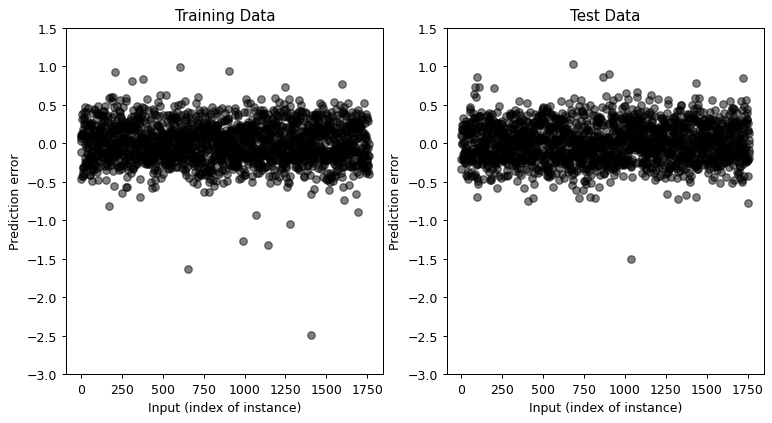

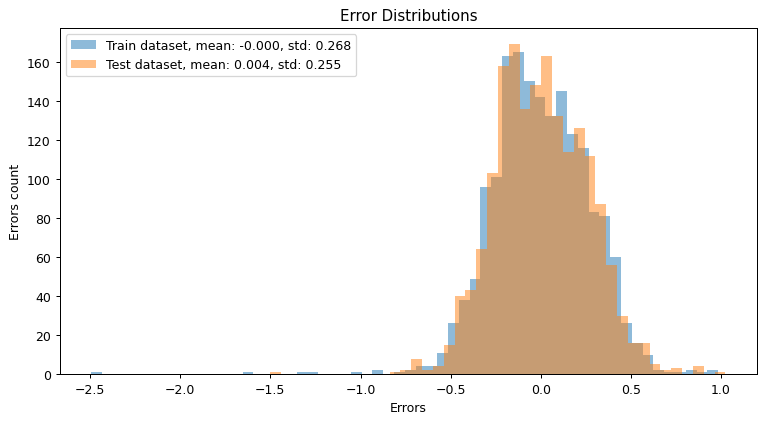

In [21]:
# plot predictions and historgrams of errors (show the model has uniform errors)
def plot_model_prediction_error(target_output : np.ndarray, model_output : np.ndarray, ax, plt_info : dict):
    ax.plot(target_output-model_output, 'ko', alpha=0.5)
    ax.set_xlabel('Input (index of instance)')
    ax.set_ylabel('Prediction error')
    ax.set_title(plt_info['title'])
    ax.set_ylim([-3, 1.5])

def plot_error_distributions(target_output : np.ndarray, model_output : np.ndarray, ax, plt_info : dict):
    errors = target_output - model_output
    label = f"{plt_info['dataset']} dataset, mean: {errors.mean():.3f}, std: {errors.std():.3f}"
    ax.hist(errors, bins='auto', alpha=0.5, label=label)
    ax.set_xlabel('Errors')
    ax.set_ylabel('Errors count')

# Plot model predictions vs true outputs
fig, axes = plt.subplots(1, 2, figsize=(10,5))
plot_model_prediction_error(y_train, predictions_train, axes[0], {'title': 'Training Data'})
plot_model_prediction_error(y_test, predictions_test, axes[1], {'title':'Test Data'})

# Plot error distributions
fig, axes = plt.subplots(1, 1, figsize=(10,5))
plot_error_distributions(y_train, predictions_train, axes, {'dataset': 'Train'})
plot_error_distributions(y_test, predictions_test, axes, {'dataset': 'Test'})
axes.legend(), axes.set_title('Error Distributions')


**TO DO 6**: Answer in ths cell (you do not need more than 5-7 lines):

1- What is the intuition behind the definition of COD, would you prefer it high or low?

2- Looking at the plots above, do you think the learning algorithm found a good value for $\hat w$? Why?

$R^2=1-\mathrm{RSS}/\mathrm{TSS}$ compares the model with a constant sample-mean prediction: higher is better, 1 is perfect, and negative values are worse than the baseline.
With seed 42, the full model achieves training $R^2=0.9283$ and test $R^2=0.9312$, supporting good predictive fit with no large generalization gap on this split.
The custom SVD coefficients agree with NumPy's global least-squares solution.
Residual centering and the plotted distributions are useful diagnostics but do not prove independent, homoscedastic Gaussian noise.
The nominal 95% prediction intervals cover 96.99% of these test observations.

## Confidence intervals for output predictions
In the following we will use d to represent the number of parameters of the linear model (which may contain the bias b).

Having estimated the extended set of coefficients $\hat w$ (remember this is the outcome of a random variable), and given a new location $x_0$, the output prediction  has the form
$$
\hat y_0 : = x_0 ^\top \hat w
$$
and postulating $X^T X$ is invertible and that 
$$
y_0 = x_0^\top w + \epsilon_0 \quad \epsilon_0 \sim {\cal N}(0,\sigma^2)
$$
where $w := \mathbb{E}[\hat{w}]$ (due to the invertibility assumption). You can think the last assumption is not that far from being true: remember the bell shaped errors we plotted before (very very close to be a gaussian)! We would like to compute a confidence interval on the output prediction or equivalently for the estimation error
$$
\tilde y_0:=\hat y_0 - y_0$$
Using the equations above we have that 
$$
\tilde y_0 =x_0^\top (\hat w - w) -  \epsilon_0
$$
where $\epsilon_0$ and $\hat w$ are uncorrelated (since $x_0$ is a new input location $\hat{w}$ does not depend on $x_0$). It thus follows that ($x_0$ is a deterministic quantity)
$$
\tilde y_0 \sim {\cal N}(0, x_0^\top {Var}\{\hat w\}x_0  + \sigma^2)
$$
where
$$
x_0^\top {Var}\{\hat w\}x_0 = \sigma^2 x_0^T (X^TX)^{-1}x_0 \quad \quad
$$
Try to compute the variance of the random variable $\hat w$ (write its equation and then substitute $Y = Xw + E$ with $E\sim \mathcal N (0, \sigma^2 I)$).

__Note__: We do not know $\sigma^2$, we must estimate it from the data!

Using the results we have seen in class (extended to the case of unknown variance) we have that the interval 
$$
[ - \Delta_0, + \Delta_0] \quad \quad \Delta_0 : = \hat\sigma \, t_{1-\frac{\alpha}{2}}(m_{t}-d) \sqrt{x_0^\top (X^\top X)^{-1}x_0 + 1} 
$$
where 
$$
t_{1-\frac{\alpha}{2}}(m_{t}-d)
$$
is the $1-\frac{\alpha}{2}$ percentile of the Student's t-distribution, and
$$
\hat\sigma^2:= \frac{1}{m_t-d}\sum_{i\in S_t} (y_i - \hat w^\top x_i)^2.
$$
The interval $[ - \Delta_0, + \Delta_0]$ satisfies the condition
$$
\mathbb{P}[\tilde y_0 \in [ - \Delta_0, + \Delta_0]] =\mathbb{P}[(\hat  y_0 - y_0) \in [ - \Delta_0, + \Delta_0]]= 1-\alpha
$$

Note that the probability is to be understood with repect to both the choice of the traning set $(Y,X)$  as well as on the choice of $y_0$. 

**Correction:** Here $d$ counts all fitted parameters, including the intercept; the residual degrees of freedom are $m_t-d$. These are prediction intervals for a new noisy observation. Confidence intervals for its conditional mean omit the additional $1$ under the square root.


In [22]:
from scipy.stats import t
alpha = 0.05
# p includes the intercept; do not subtract it a second time.
p = x_train.shape[1]
dof = len(x_train) - p
t_percentile = t.ppf(1 - alpha / 2, dof)
sigma_2_hat = rss(y_train, linear_predictions(w_hat, x_train)) / dof
xtx_inv = np.linalg.inv(x_train.T @ x_train)
leverage = np.einsum('ij,jk,ik->i', x_test, xtx_inv, x_test)
delta_0 = t_percentile * np.sqrt(sigma_2_hat * (1 + leverage))
ci_O = np.column_stack((-delta_0, delta_0))
print("95% prediction-error intervals:", ci_O, "shape:", ci_O.shape)
print("Empirical coverage:", np.mean(np.abs((predictions_test-y_test).ravel()) <= delta_0))


95% prediction-error intervals: [[-0.52664845  0.52664845]
 [-0.52729573  0.52729573]
 [-0.5262321   0.5262321 ]
 ...
 [-0.52639382  0.52639382]
 [-0.52651136  0.52651136]
 [-0.52714819  0.52714819]] shape: (1761, 2)
Empirical coverage: 0.9699034639409426


In [23]:
assert x_train.shape[1] == w_hat.shape[0]
assert x_test.shape[1] == w_hat.shape[0]
assert ci_O.shape[0] == x_test.shape[0]
assert ci_O.shape[1] == 2


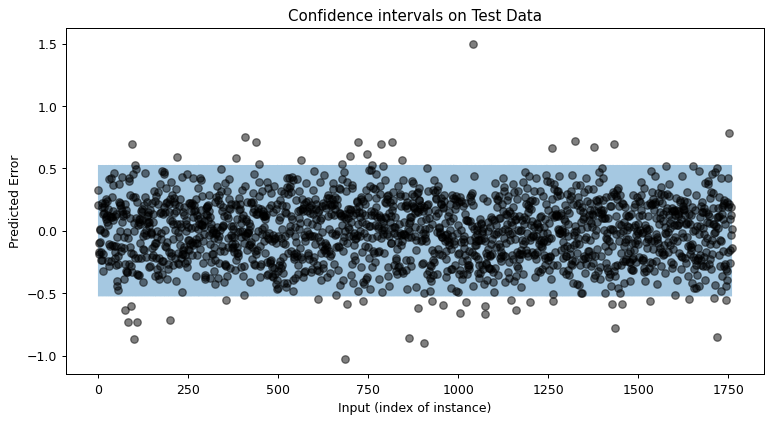

In [24]:
def plot_model_predictions_error_vs_CI(target_output : np.ndarray, model_output : np.ndarray, c_i : np.ndarray, ax, 
                                 plt_info : dict):
    ax.plot(model_output-target_output, 'ko', alpha=0.5)
    ax.fill_between(range(model_output.shape[0]),c_i[:,0], c_i[:,1], alpha=0.4)

    ax.set_xlabel('Input (index of instance)')
    ax.set_ylabel('Predicted Error')
    ax.set_title(plt_info['title'])

fig, ax = plt.subplots(1, 1, figsize=(10,5))
plot_model_predictions_error_vs_CI(y_test, predictions_test, ci_O, ax, {'title': 'Confidence intervals on Test Data'})


Why do we need the validation dataset? 
Up to now we have not used it! But up to now we have not tried to find the best hyper-parameters for our linear model.
Now we are going to find the best subset of features (and therefore the best coefficients) according to RSS or COD evaluated using the validation. 
In this very simple case we are going to use a brute force approach, we will try every single possible combination of features and evaluate the trained model using the validation dataset.

Since our model now depends on the validation dataset we should not use the validation dataset to evaluate the generalization capability of the new model, that is why we need a "new" dataset (that we have not used to optimize our model): the test dataset.

[(0,), (1,), (2,), (3,), (4,)]
[(0, 1), (0, 2), (0, 3), (0, 4), (1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]
[(0, 1, 2), (0, 1, 3), (0, 1, 4), (0, 2, 3), (0, 2, 4), (0, 3, 4), (1, 2, 3), (1, 2, 4), (1, 3, 4), (2, 3, 4)]
[(0, 1, 2, 3), (0, 1, 2, 4), (0, 1, 3, 4), (0, 2, 3, 4), (1, 2, 3, 4)]
[(0, 1, 2, 3, 4)]
Best subset of features according to training: (0, 1, 2, 3, 4)
Best subset of features according to validation: (0, 1, 2, 4)
Test metrics for the best model: rss 115.3751, cod 0.9307


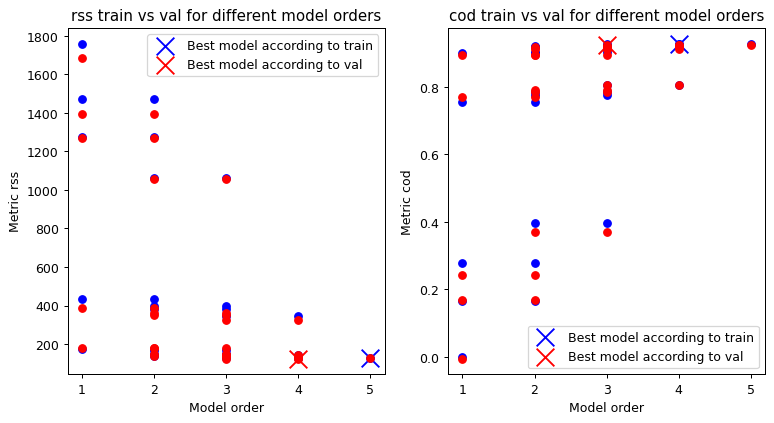

In [25]:
from itertools import combinations
from collections import defaultdict

# Let's use the functions we built up to now to find the best model order according the validation criterions.
# Once we choose the best model order, which is an hyper-parameters we will estimate its generalization
# capability using the test dataset! 

indexes_subset, train_metrics, val_metrics = [], defaultdict(list), defaultdict(list)
for k in range(1, x_train.shape[1] + 1):
    print(list(combinations(list(range(x_train.shape[1])), k)))
    all_combinations_given_k_choices = list(combinations(list(range(x_train.shape[1])), k))
    for indexes in all_combinations_given_k_choices:
        indexes_subset.append(indexes)
        x_train_subset, x_val_subset = x_train[:, indexes], x_val[:, indexes]
        w_hat = compute_LS_optimal_ERM_coefficients(x_train_subset, y_train)
        # Predict Training metrics
        predictions_train = linear_predictions(w_hat, x_train_subset)
        rss_hand_train, cod_hand_train = rss(y_train, predictions_train), cod(y_train, predictions_train)
        train_metrics['rss'].append(rss_hand_train)
        train_metrics['cod'].append(cod_hand_train)
        # Predict Generalization metrics (using the validation set)
        predictions_val = linear_predictions(w_hat, x_val_subset)
        rss_hand_val, cod_hand_val = rss(y_val, predictions_val), cod(y_val, predictions_val)
        val_metrics['rss'].append(rss_hand_val)
        val_metrics['cod'].append(cod_hand_val)   

# Let's find which is the best model according to the validation error 
def plot_metric_vs_model_order(indexes_subset, metric_results, ax, plot_info):
    for indexes, metric in zip(indexes_subset, metric_results):
        ax.scatter(len(indexes), metric, color=plot_info['color'])
    # Find best model 
    best_index = np.argmax(metric_results) if plot_info['metric'] == 'cod' else np.argmin(metric_results)
    ax.scatter(len(indexes_subset[best_index]), metric_results[best_index], color=plot_info['color'], marker='x', 
               s=200, label=f"Best model according to {plot_info['dataset']}")

    ax.set_xlabel('Model order')
    ax.set_ylabel(f"Metric {plot_info['metric']}")
    ax.set_title(f"{plot_info['metric']} train vs val for different model orders")
    ax.legend()
    return indexes_subset[best_index]
    
fig, axes = plt.subplots(1,2, figsize=(10, 5))
# RSS metric
best_features_subset_train = plot_metric_vs_model_order(indexes_subset, train_metrics['rss'], axes[0], 
                           {'color': 'blue', 'dataset': 'train', 'metric': 'rss'})
best_features_subset_val = plot_metric_vs_model_order(indexes_subset, val_metrics['rss'], axes[0], 
                           {'color': 'red', 'dataset': 'val', 'metric': 'rss'})
print(f'Best subset of features according to training: {best_features_subset_train}')
print(f'Best subset of features according to validation: {best_features_subset_val}')
# COD metric
plot_metric_vs_model_order(indexes_subset, train_metrics['cod'], axes[1], 
                           {'color': 'blue', 'dataset': 'train', 'metric': 'cod'})
plot_metric_vs_model_order(indexes_subset, val_metrics['cod'], axes[1], 
                           {'color': 'red', 'dataset': 'val', 'metric': 'cod'})

# We now evaluate the best model (you can choose if you prefer COD or RSS as criterion) on the test dataset
w_hat = compute_LS_optimal_ERM_coefficients(x_train[:, best_features_subset_val], y_train)
predictions_test_best = linear_predictions(w_hat, x_test[:,best_features_subset_val])
rss_hand_test_best, cod_hand_test_best = rss(y_test, predictions_test_best), cod(y_test, predictions_test_best)
print(f"Test metrics for the best model: rss {rss_hand_test_best:.4f}, cod {cod_hand_test_best:.4f}")


**TO DO 8**:
Compute the confidence intervals of $\hat w$ for the model with 5 parameteres (Use what you have learned during class)



In [26]:
w_hat = compute_LS_optimal_ERM_coefficients(x_train, y_train)
predictions_test = linear_predictions(w_hat, x_test)
rss_hand_test, cod_hand_test = rss(y_test, predictions_test), cod(y_test, predictions_test)
dof = len(x_train) - x_train.shape[1]
sigma_2_hat = rss(y_train, linear_predictions(w_hat, x_train)) / dof
cov_w_hat = sigma_2_hat * np.linalg.inv(x_train.T @ x_train)
coefficient_se = np.sqrt(np.diag(cov_w_hat))
coefficient_delta = t.ppf(0.975, dof) * coefficient_se
ci_w = np.column_stack((w_hat.ravel()-coefficient_delta, w_hat.ravel()+coefficient_delta))
print(pd.DataFrame({'estimate': w_hat.ravel(), 'lower_95': ci_w[:,0], 'upper_95': ci_w[:,1]}))
zero_in_ci = (ci_w[:,0] <= 0) & (ci_w[:,1] >= 0)
print("Coefficient indices whose intervals contain zero:", np.flatnonzero(zero_in_ci))
print("Validation-selected indices:", best_features_subset_val)


       estimate  lower_95  upper_95
0  1.013079e-15 -0.012536  0.012536
1 -8.617318e-01 -0.892465 -0.830998
2 -1.703969e-01 -0.195319 -0.145475
3  2.596545e-02  0.010874  0.041057
4 -1.262764e-01 -0.142787 -0.109765
Coefficient indices whose intervals contain zero: [0]
Validation-selected indices: (0, 1, 2, 4)


**TO DO 9**:

1-Based on these confidence intervals could you conclude that a paramiter is not that useful?

2-Compare these results with the one obtained in the previous section where we evaluated the best model order. Do they lead to a similar conclusion? Why? 

All four slope confidence intervals exclude zero in this run; only the intercept interval contains zero, as expected after centering both features and target. Thus individual 5% tests do not identify an insignificant slope under the model assumptions.
Validation nevertheless selects design columns $(0,1,2,4)$, omitting slope column 3 (zero-based indexing; column 0 is the intercept). Its test $R^2=0.9307$ is almost identical to the full model's $0.9312$.
The methods therefore do not select exactly the same model: coefficient significance and best predictive performance are different criteria. Correlated features can have statistically nonzero conditional effects with only a small practical predictive contribution. These are individual, not simultaneous, intervals.